**بسم الله الرحمن الرحیم**

# 1

## 1.1

> **`پاسخ در گزارش کار آورده شده است.`**





## 1.2


> **`پاسخ در گزارش کار آورده شده است.`**



## 1.3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex


In [ ]:
#define Neuron Class
class McCulloch_Pitts_neuron():

  def __init__(self , weights , threshold):
    self.weights = weights    #define weights
    self.threshold = threshold    #define threshold

  def model(self , x):
    #define model with threshold
    if self.weights @ x >= self.threshold:
        return 1
    else:
        return 0

In [ ]:
#define Perceptron Class
class Perceptron():
    def __init__(self, weights, bias, activation_function=None):
        self.weights = np.array(weights)
        self.bias = bias
        self.activation_function = activation_function if activation_function else lambda x: 1 if x >= 0 else 0

    def model(self, x):
        return self.activation_function(np.dot(x, self.weights) + self.bias)

In [ ]:
# with McCulloch_Pitts_neuron
def is_in_triangle (x , y):
  neuron1_1 = McCulloch_Pitts_neuron([0,1] , 0)
  neuron1_2 = McCulloch_Pitts_neuron([-2,-1] , -6)
  neuron1_3 = McCulloch_Pitts_neuron([2,-1] , 2)
  neuron2_1 = McCulloch_Pitts_neuron([1,1,1] , 2.5)

  z1 = neuron1_1.model(np.array([x, y]))
  z2 = neuron1_2.model(np.array([x, y]))
  z3 = neuron1_3.model(np.array([x, y]))
  z4 = neuron2_1.model(np.array([z1,z2,z3]))

  return z4


In [ ]:
# with Perceprton
def is_in_triangle_2 (x , y):
  neuron1_1 = Perceptron([0,1] , 0)
  neuron1_2 = Perceptron([-2,-1] , 6)
  neuron1_3 = Perceptron([2,-1] , -2)
  neuron2_1 = Perceptron([1,1,1] , -2.5)

  z1 = neuron1_1.model(np.array([x, y]))
  z2 = neuron1_2.model(np.array([x, y]))
  z3 = neuron1_3.model(np.array([x, y]))
  z4 = neuron2_1.model(np.array([z1,z2,z3]))

  return z4

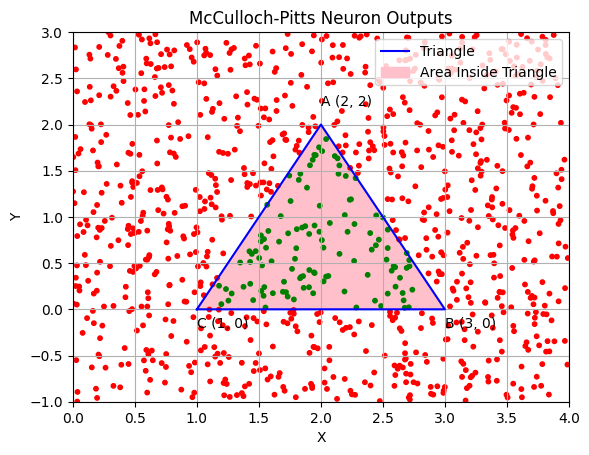

In [ ]:
# create sample data (points)
sample_size = 1000
x = np.random.uniform(0, 4, sample_size)
y = np.random.uniform(-1, 3, sample_size)

colors = []

for i in range(sample_size):
    if is_in_triangle(x[i], y[i]):
        colors.append('green')
    else:
        colors.append('red')

def plot_triangle(x, y, colors):
    # Define the vertices of a triangle
    tri_x = [1, 3, 2, 1]
    tri_y = [0, 0, 2, 0]

    fig, ax = plt.subplots()
    ax.plot(tri_x, tri_y, color='blue', label='Triangle')
    ax.fill(tri_x, tri_y, color='pink', hatch='//', label='Area Inside Triangle')

    ax.grid(True)
    ax.set_xlim(0, 4)
    ax.set_ylim(-1, 3)
    ax.set_title('Graph with Lines and Hatched Area (Triangle)')
    ax.legend(loc='upper right')

    # Add annotations for triangle vertices
    ax.annotate('C (1, 0)', xy=(1, 0), xytext=(1, -0.2))
    ax.annotate('A (2, 2)', xy=(2, 2), xytext=(2, 2.2))
    ax.annotate('B (3, 0)', xy=(3, 0), xytext=(3, -0.2))

    plt.scatter(x, y, c=colors, s=10)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('McCulloch-Pitts Neuron Outputs')
    plt.show()

plot_triangle(x,y,colors)

In [ ]:
# Define activation functions
def elu(x, alpha=1):
    return x if x > 0 else alpha * (np.exp(x) - 1)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

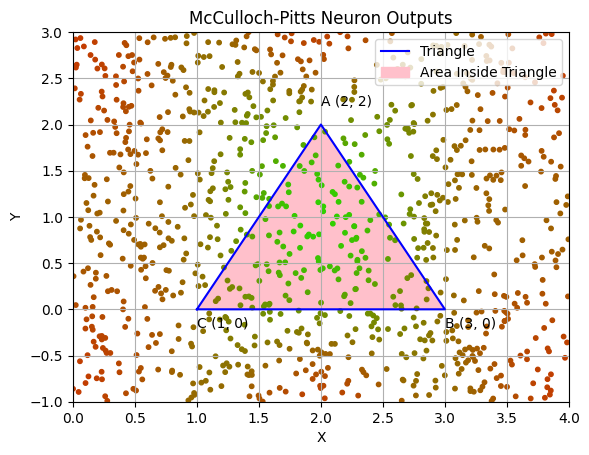

In [ ]:
def is_in_triangle_3(x, y): # with activation function
    # Neurons in the first layer with ELU activation
    # neuron1_1 = Perceptron([0, 1], 0,activation_function=lambda x: np.where((x >= 0) & (x <= 2), 1, 0))
    # neuron1_2 = Perceptron([-2, -1], 6,activation_function=lambda x : np.where((x >= 0) & (x <= 2), 1, 0))
    # neuron1_3 = Perceptron([2, -1], -2,activation_function=lambda x : np.where((x >= 0) & (x <= 2), 1, 0))
    mean = 1
    variance = 1
    neuron1_1 = Perceptron([0, 1], 0,activation_function=lambda x: np.exp(-((x - mean)**2) / (2 * variance)))
    neuron1_2 = Perceptron([-2, -1], 6,activation_function=lambda x : np.exp(-((x - mean)**2) / (2 * variance)))
    neuron1_3 = Perceptron([2, -1], -2,activation_function=lambda x : np.exp(-((x - mean)**2) / (2 * variance)))
    # Neuron in the second layer with Sigmoid activation
    neuron2_1 = Perceptron([1, 1, 1],-1.5, activation_function=sigmoid)
    # Compute outputs for the first layer
    z1 = neuron1_1.model(np.array([x, y]))
    z2 = neuron1_2.model(np.array([x, y]))
    z3 = neuron1_3.model(np.array([x, y]))

    # Compute output for the second layer
    z4 = neuron2_1.model(np.array([z1, z2, z3]))
    # print(f'z1 {z1}')
    # print(f'z2 {z2}')
    # print(f'z3 {z3}')
    # print(f'z4 {z4}')

    return z4

sample_size = 1000
x = np.random.uniform(0, 4, sample_size)
y = np.random.uniform(-1, 3, sample_size)

colors = []

for i in range(sample_size):
    # print(x[i], y[i])
    intensity = is_in_triangle_3(x[i], y[i])
    color = to_hex([1 - intensity, intensity, 0])  # Linear interpolation between red and green
    colors.append(color)

plot_triangle(x, y, colors)

# 2

## 2.1

آپلود دیتاست

In [ ]:
!pip install --upgrade --no-cache-dir gdown
!gdown 1N9NIk8b-ikS5CFoBywe6RFmKjgKILira

Downloading...
From: https://drive.google.com/uc?id=1N9NIk8b-ikS5CFoBywe6RFmKjgKILira
To: /content/teleCust1000t.csv
100% 37.0k/37.0k [00:00<00:00, 71.5MB/s]


## 2.2

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

(1000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   1000 non-null   int64  
 1   tenure   1000 non-null   int64  
 2   age      1000 non-null   int64  
 3   marital  1000 non-null   int64  
 4   address  1000 non-null   int64  
 5   income   1000 non-null   float64
 6   ed       1000 non-null   int64  
 7   employ   1000 non-null   int64  
 8   retire   1000 non-null   float64
 9   gender   1000 non-null   int64  
 10  reside   1000 non-null   int64  
 11  custcat  1000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 93.9 KB


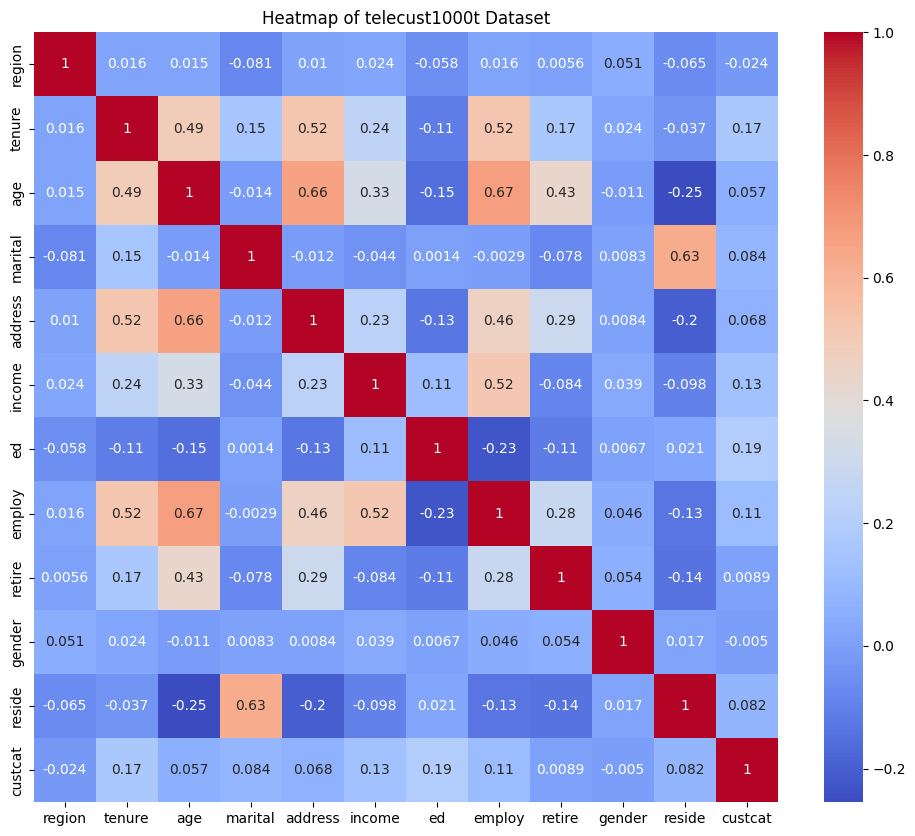

--------------------------------------


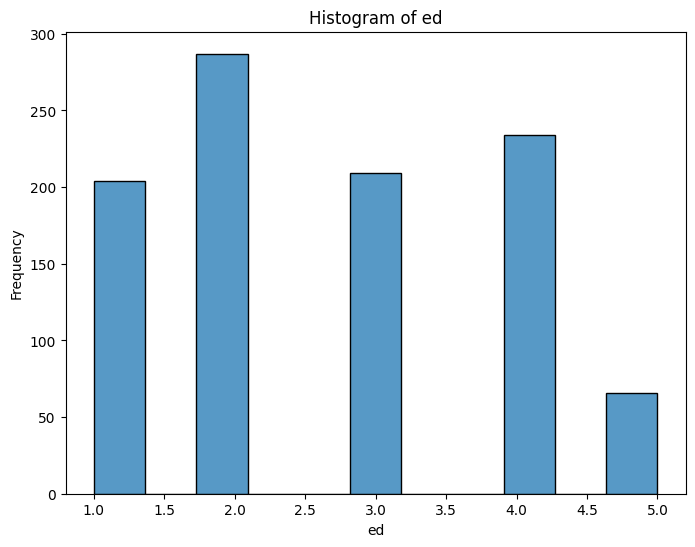

--------------------------------------


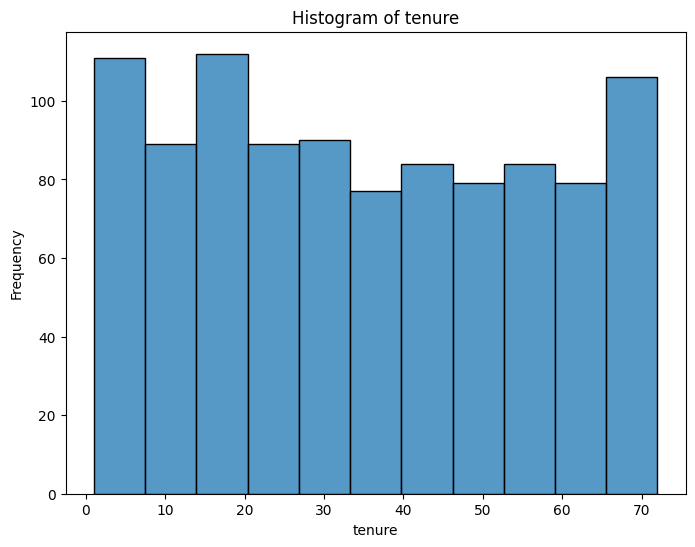

--------------------------------------
Class Distribution:
custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64


<ipython-input-44-2f8c8cbb064d>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')


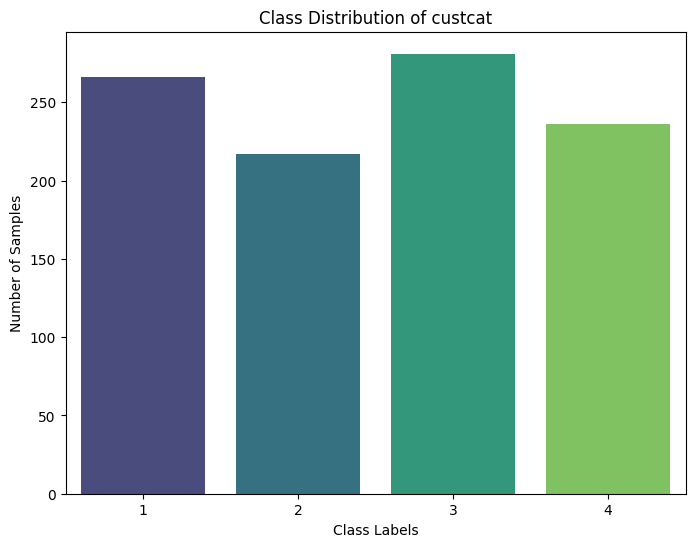

In [ ]:
#import and seprate da

data = pd.read_csv('/content/teleCust1000t.csv')
y = data['custcat']
X = data.drop('custcat', axis=1)

print(data.shape)
data.info()

plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of telecust1000t Dataset')
plt.show()
print("--------------------------------------")
# target_corr = data.corr()['custcat'].abs().sort_values(ascending=False)
# top_features = target_corr[1:3].index.tolist()

for feature in ['ed','tenure']:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[feature])
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()
    print("--------------------------------------")

class_distribution = data['custcat'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Class Distribution of custcat')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.show()

## 2.3

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import tensorflow as tf
import random
! pip install torch-adopt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.config.experimental.enable_op_determinism()
np.random.seed(13)
random.seed(13)
tf.random.set_seed(13)

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=13, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.30, random_state=13, stratify=y_test)
# 70% train   20% test    10% validataion
X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape

((700, 11), (210, 11), (90, 11), (700,), (210,), (90,))

## 2.4

In [ ]:
# 1 hidden layer model
tf.random.set_seed(13)
np.random.seed(13)
def build_model_1(hidden_units, normalize=False, dropout_rate=0.0, regularization=None):
    model = Sequential()
    model.add(Dense(hidden_units, activation='relu', input_shape=(X_train.shape[1],),
                    kernel_regularizer=regularization))
    if normalize:
        model.add(BatchNormalization())
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(y.nunique(), activation='softmax'))
    return model

# 2 hidden layer model
def build_model_2(hidden_units_1, hidden_units_2, normalize=False, dropout_rate=0.0, regularization=None):
    model = Sequential()
    model.add(Dense(hidden_units_1, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularization))
    if normalize:
        model.add(BatchNormalization())
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(hidden_units_2, activation='relu', kernel_regularizer=regularization))
    if normalize:
        model.add(BatchNormalization())
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(y.nunique(), activation='softmax'))
    return model


# train_and_evaluate function
def train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=1):
    y_train = to_categorical(y_train-1, num_classes=4)
    y_test = to_categorical(y_test-1,num_classes=4)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=verbose)
    val_acc = history.history['val_accuracy'][-1]
    return model, val_acc

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 2 neurons: Validation Accuracy = 0.3733333349227905


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 4 neurons: Validation Accuracy = 0.4000000059604645


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Model with 16 neurons: Validation Accuracy = 0.4266666769981384


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 32 neurons: Validation Accuracy = 0.41333332657814026


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 64 neurons: Validation Accuracy = 0.41333332657814026


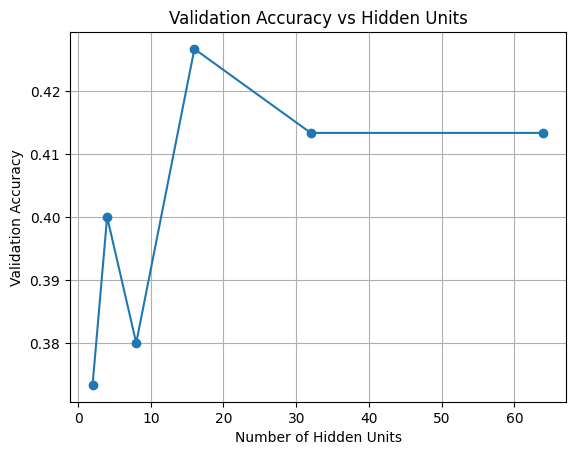

In [ ]:
#CHECKS neuron numbers for 1 layer
validation_accuracies = []
for hidden_units in [2, 4, 8, 16, 32, 64]:
    model = build_model_1(hidden_units=hidden_units)
    optimizer = SGD(learning_rate=0.01, momentum=0.9)
    _, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
    print(f"Model with {hidden_units} neurons: Validation Accuracy = {val_acc}")
    validation_accuracies.append(val_acc)

hidden_units_list = [2, 4, 8, 16, 32, 64]
plt.plot(hidden_units_list, validation_accuracies, marker='o')
plt.title('Validation Accuracy vs Hidden Units')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 2 neurons: Validation Accuracy = 0.30000001192092896


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 4 neurons: Validation Accuracy = 0.31111112236976624


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Model with 16 neurons: Validation Accuracy = 0.3333333432674408


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 32 neurons: Validation Accuracy = 0.2888889014720917


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 64 neurons: Validation Accuracy = 0.3222222328186035


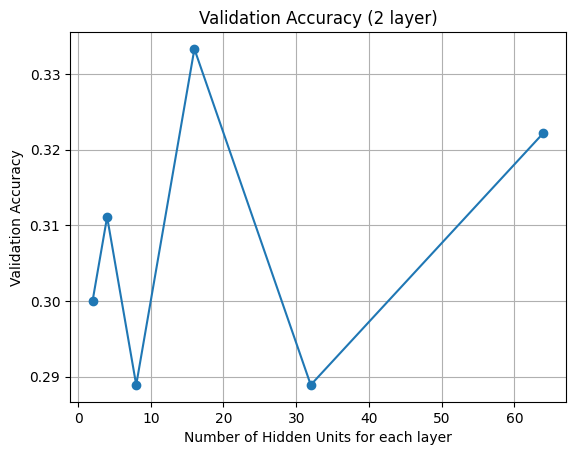

In [ ]:
#CHECKS neuron numbers for 2 layer
validation_accuracies = []
for hidden_units in [2, 4, 8, 16, 32, 64]:
    model = build_model_2(hidden_units_1=hidden_units, hidden_units_2= hidden_units )
    optimizer = SGD(learning_rate=0.01, momentum=0.9)
    _, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
    print(f"Model with {hidden_units} neurons: Validation Accuracy = {val_acc}")
    validation_accuracies.append(val_acc)

hidden_units_list = [2, 4, 8, 16, 32, 64]
plt.plot(hidden_units_list, validation_accuracies, marker='o')
plt.title('Validation Accuracy (2 layer)')
plt.xlabel('Number of Hidden Units for each layer')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 2 neurons: Validation Accuracy = 0.30000001192092896


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 4 neurons: Validation Accuracy = 0.3222222328186035


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Model with 16 neurons: Validation Accuracy = 0.35555556416511536


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 32 neurons: Validation Accuracy = 0.3444444537162781


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 64 neurons: Validation Accuracy = 0.35555556416511536


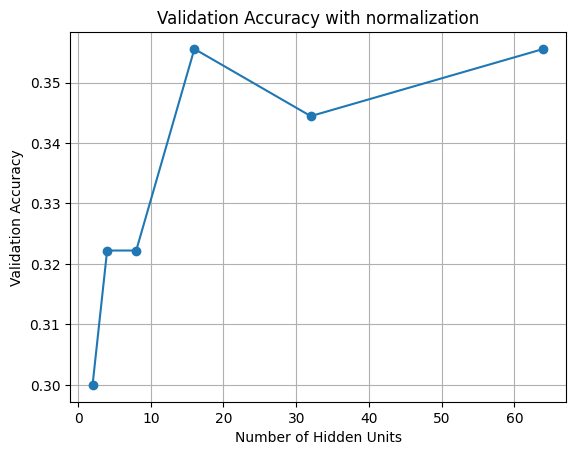

In [ ]:
#CHECKS normalization for 1 layer
validation_accuracies = []
for hidden_units in [2, 4, 8, 16, 32, 64]:
    model = build_model_1(hidden_units=hidden_units, normalize=True)
    optimizer = SGD(learning_rate=0.01, momentum=0.9)
    _, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
    print(f"Model with {hidden_units} neurons: Validation Accuracy = {val_acc}")
    validation_accuracies.append(val_acc)

hidden_units_list = [2, 4, 8, 16, 32, 64]
plt.plot(hidden_units_list, validation_accuracies, marker='o')
plt.title('Validation Accuracy with normalization')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 2 neurons: Validation Accuracy = 0.31904762983322144


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 4 neurons: Validation Accuracy = 0.36666667461395264


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Model with 16 neurons: Validation Accuracy = 0.3333333432674408


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 32 neurons: Validation Accuracy = 0.3333333432674408


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with 64 neurons: Validation Accuracy = 0.36666667461395264


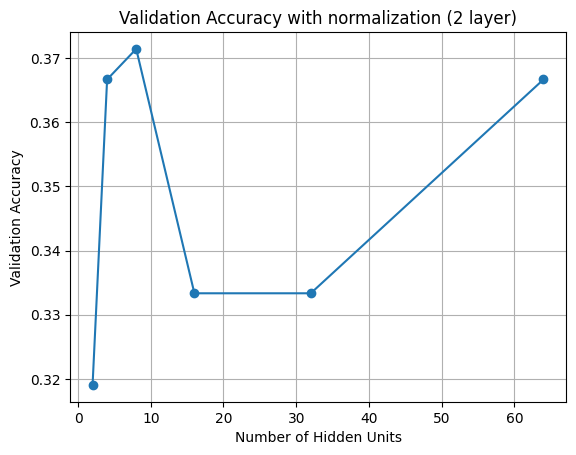

In [ ]:
#CHECKS normalization for 2 layer
validation_accuracies = []
for hidden_units in [2, 4, 8, 16, 32, 64]:
    model = build_model_2(hidden_units_1 = hidden_units, hidden_units_2 = hidden_units, normalize=True)
    optimizer = SGD(learning_rate=0.01, momentum=0.9)
    _, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
    print(f"Model with {hidden_units} neurons: Validation Accuracy = {val_acc}")
    validation_accuracies.append(val_acc)

hidden_units_list = [2, 4, 8, 16, 32, 64]
plt.plot(hidden_units_list, validation_accuracies, marker='o')
plt.title('Validation Accuracy with normalization (2 layer)')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# CHECK Dropout 2 layer 8*8 neuron
model = build_model_2(8,8, normalize=True, dropout_rate=0.5)
optimizer = SGD(learning_rate=0.01, momentum=0.9)
_, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
print(f"Model with Dropout: Validation Accuracy (2 layer 8*8 neuron) = {val_acc}")

# CHECK Dropout 1 layer 16 neuron

model = build_model_1(16, normalize=True, dropout_rate=0.5)
optimizer = SGD(learning_rate=0.01, momentum=0.9)
_, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
print(f"Model with Dropout: Validation Accuracy (1 layer 16 neuron) = {val_acc}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with Dropout: Validation Accuracy (2 layer 8*8 neuron) = 0.39047619700431824


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with Dropout: Validation Accuracy (1 layer 16 neuron) = 0.4047619104385376


In [ ]:
# CHECK L2-Regularization 2 layer 8*8 neuron
model = build_model_2(8,8, normalize=True, regularization=l2(0.0001))
optimizer = SGD(learning_rate=0.01, momentum=0.9)
_, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
print(f"Model with L2-Regularization: Validation Accuracy 2 layer 8*8 = {val_acc}")


# CHECK L2-Regularization 1 layer 16 neuron
model = build_model_1(16, normalize=True,regularization=l2(0.0001))
optimizer = SGD(learning_rate=0.01, momentum=0.9)
_, val_acc = train_and_evaluate(model, optimizer, X_train, y_train, X_test, y_test, verbose=0)
print(f"Model with L2-Regularization: Validation Accuracy 1 layer 16 neouron = {val_acc}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with L2-Regularization: Validation Accuracy 2 layer 8*8 = 0.4000000059604645


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model with L2-Regularization: Validation Accuracy 1 layer 16 neouron = 0.4000000059604645


In [ ]:
#CHECK with optimizer 1 layer 16 neuron
for opt in [Adam(learning_rate=0.01), RMSprop(learning_rate=0.01)]: #, ADOPT(model.parameters(), lr=1e-3) is for pytorch :(
    model = build_model_1(16, normalize=True,)
    _, val_acc = train_and_evaluate(model, opt, X_train, y_train, X_test, y_test, verbose=0)
    print(f"Model 1 layer 16 neuron with {opt.__class__.__name__}: Validation Accuracy = {val_acc}")

#CHECK with optimizer 2 layer 8*8 neuron
for opt in [Adam(learning_rate=0.01), RMSprop(learning_rate=0.01)]: #, ADOPT(model.parameters(), lr=1e-3) is for pytorch :(
    model = build_model_2(8,8, normalize=True,)
    _, val_acc = train_and_evaluate(model, opt, X_train, y_train, X_test, y_test, verbose=0)
    print(f"Model 2 layer 8** neuron with {opt.__class__.__name__}: Validation Accuracy = {val_acc}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 layer 16 neuron with Adam: Validation Accuracy = 0.35333332419395447


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 layer 16 neuron with RMSprop: Validation Accuracy = 0.3466666638851166


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 2 layer 8** neuron with Adam: Validation Accuracy = 0.36000001430511475


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 2 layer 8** neuron with RMSprop: Validation Accuracy = 0.3799999952316284


## زیادی

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.regularizers import l2


X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. تعریف توابع کمکی برای ساخت مدل‌ها
def create_model_1layer(neurons, batch_norm=False, dropout_rate=None, regularization=None):
    model = Sequential()

    if regularization:
        reg = l2(regularization)
    else:
        reg = None

    model.add(Dense(neurons, activation='relu', kernel_regularizer=reg, input_shape=(X_train.shape[1],)))

    if batch_norm:
        model.add(BatchNormalization())
    if dropout_rate:
        model.add(Dropout(dropout_rate))

    model.add(Dense(4, activation='softmax'))
    return model

def create_model_2layers(neurons1, neurons2, batch_norm=False, dropout_rate=None, regularization=None):
    model = Sequential()

    if regularization:
        reg = l2(regularization)
    else:
        reg = None

    model.add(Dense(neurons1, activation='relu', kernel_regularizer=reg, input_shape=(X_train.shape[1],)))
    if batch_norm:
        model.add(BatchNormalization())
    if dropout_rate:
        model.add(Dropout(dropout_rate))

    model.add(Dense(neurons2, activation='relu', kernel_regularizer=reg))
    if batch_norm:
        model.add(BatchNormalization())
    if dropout_rate:
        model.add(Dropout(dropout_rate))

    model.add(Dense(4, activation='softmax'))
    return model

# آزمایش تعداد نورون‌های مختلف
neurons_configs = {
    '1layer': [16, 32],
    '2layers': [(16, 8), (32, 16)]
}

results = []

# تست مدل‌ها با تنظیمات مختلف
for layer_type in ['1layer', '2layers']:
    for neurons in neurons_configs[layer_type]:
        # ... (other configurations) ...

        # Modify this line to subtract 1 from y_train and y_val
        history = model.fit(X_train, y_train - 1, validation_data=(X_val, y_val - 1), epochs=50, batch_size=32, verbose=0)


        val_acc = max(history.history['val_accuracy'])
        results.append({
            'model': f"{layer_type}_{neurons}",
            'config': 'base',
            'val_acc': val_acc
        })

        # تست با BatchNormalization
        if layer_type == '1layer':
            model = create_model_1layer(neurons, batch_norm=True)
        else:
            model = create_model_2layers(neurons[0], neurons[1], batch_norm=True)

        model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history = model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=50, batch_size=32, verbose=0)

        val_acc = max(history.history['val_accuracy'])
        results.append({
            'model': f"{layer_type}_{neurons}",
            'config': 'batch_norm',
            'val_acc': val_acc
        })

        # تست با Dropout
        if layer_type == '1layer':
            model = create_model_1layer(neurons, dropout_rate=0.2)
        else:
            model = create_model_2layers(neurons[0], neurons[1], dropout_rate=0.2)

        model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history = model.fit(X_train, y_train -1, validation_data=(X_val, y_val-1), epochs=50, batch_size=32, verbose=0)

        val_acc = max(history.history['val_accuracy'])
        results.append({
            'model': f"{layer_type}_{neurons}",
            'config': 'dropout',
            'val_acc': val_acc
        })

        # تست با L2 Regularization
        if layer_type == '1layer':
            model = create_model_1layer(neurons, regularization=0.0001)
        else:
            model = create_model_2layers(neurons[0], neurons[1], regularization=0.0001)

        model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history = model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=50, batch_size=32, verbose=0)

        val_acc = max(history.history['val_accuracy'])
        results.append({
            'model': f"{layer_type}_{neurons}",
            'config': 'l2',
            'val_acc': val_acc
        })

        # تست با Adam
        if layer_type == '1layer':
            model = create_model_1layer(neurons)
        else:
            model = create_model_2layers(neurons[0], neurons[1])

        model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history = model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=50, batch_size=32, verbose=0)

        val_acc = max(history.history['val_accuracy'])
        results.append({
            'model': f"{layer_type}_{neurons}",
            'config': 'adam',
            'val_acc': val_acc
        })

# نمایش نتایج
results_df = pd.DataFrame(results)
print("\nنتایج ارزیابی مدل‌ها:")
print(results_df)

# یافتن بهترین مدل
best_result = results_df.loc[results_df['val_acc'].idxmax()]
print(f"\nبهترین مدل: {best_result['model']} با پیکربندی {best_result['config']}")
print(f"دقت اعتبارسنجی: {best_result['val_acc']:.4f}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo


نتایج ارزیابی مدل‌ها:
               model      config   val_acc
0          1layer_16        base  0.386667
1          1layer_16  batch_norm  0.413333
2          1layer_16     dropout  0.320000
3          1layer_16          l2  0.326667
4          1layer_16        adam  0.406667
5          1layer_32        base  0.400000
6          1layer_32  batch_norm  0.453333
7          1layer_32     dropout  0.360000
8          1layer_32          l2  0.380000
9          1layer_32        adam  0.373333
10   2layers_(16, 8)        base  0.406667
11   2layers_(16, 8)  batch_norm  0.386667
12   2layers_(16, 8)     dropout  0.313333
13   2layers_(16, 8)          l2  0.346667
14   2layers_(16, 8)        adam  0.386667
15  2layers_(32, 16)        base  0.413333
16  2layers_(32, 16)  batch_norm  0.400000
17  2layers_(32, 16)     dropout  0.380000
18  2layers_(32, 16)          l2  0.333333
19  2layers_(32, 16)        adam  0.400000

بهترین مدل: 1layer_32 با پیکربندی batch_norm
دقت اعتبارسنجی: 0.4533


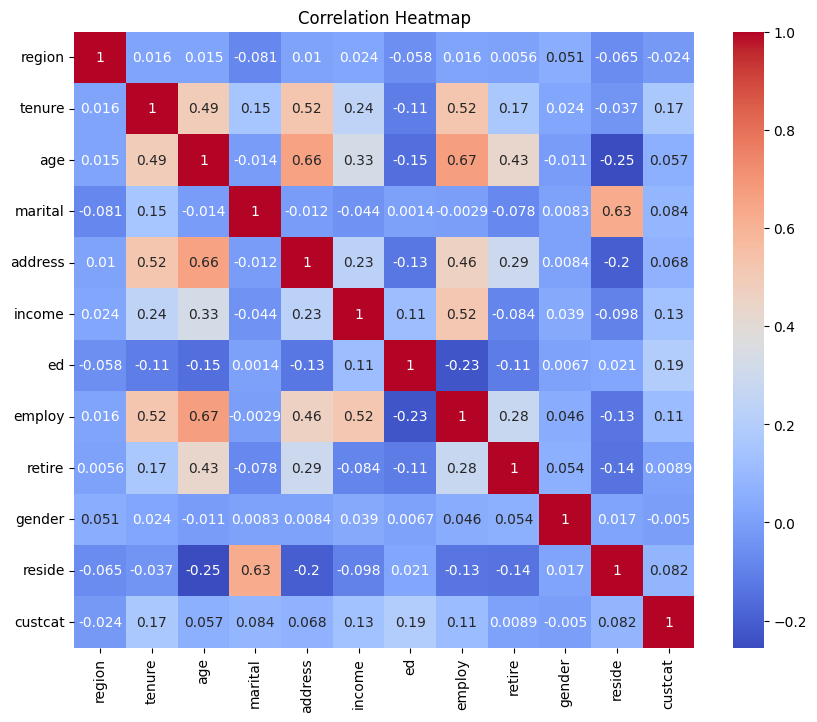

Most correlated features: Index(['ed', 'tenure'], dtype='object')


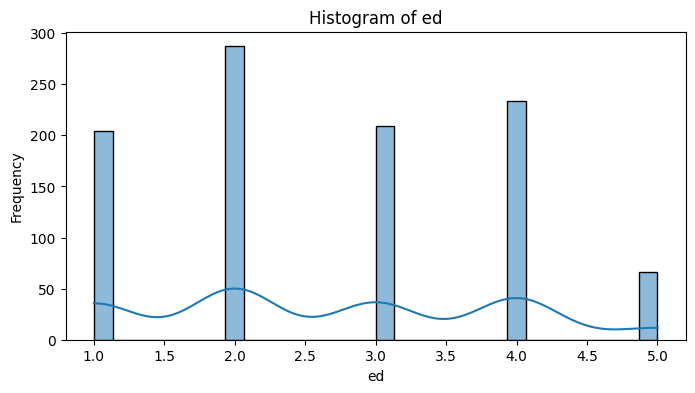

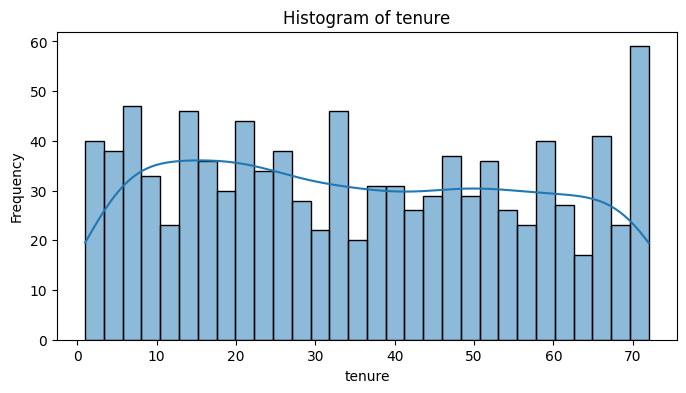

Testing model with 16 neurons


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.3267
Testing model with 32 neurons


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.2800
Testing model with batch normalization


...

Validation Accuracy with Dropout: 0.4267
Testing model with L2-Regularization


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy with L2-Regularization: 0.4133
Testing model with Adam optimizer


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy with Adam Optimizer: 0.3733
Test Accuracy: 0.4133
Test Accuracy: 0.4133


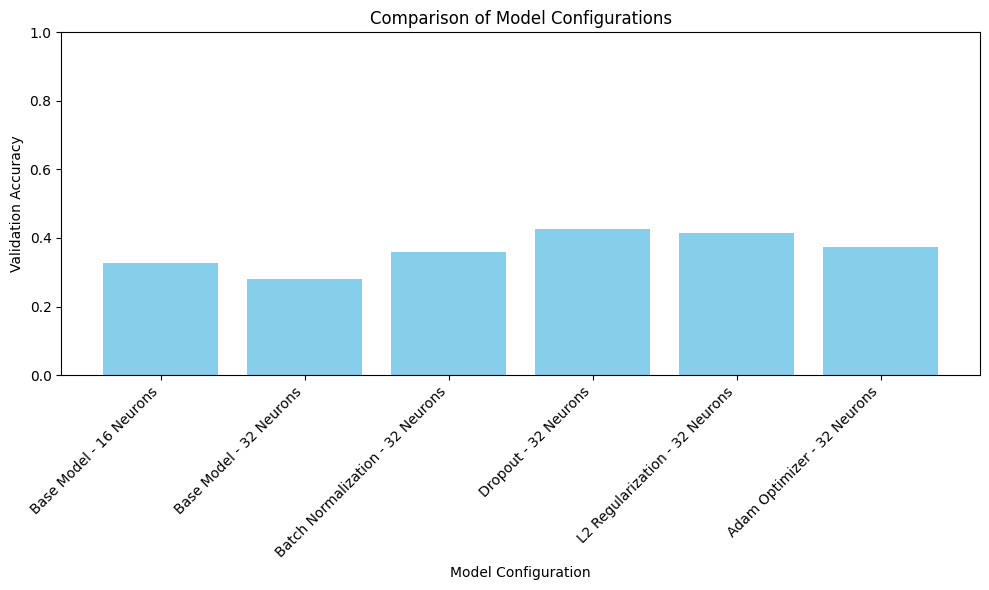

In [ ]:
def create_single_layer_model(input_dim, n_neurons, use_batch_norm=False, dropout_rate=0.0, l2_rate=0.0):
    model = Sequential()
    model.add(Dense(n_neurons, activation='relu', input_dim=input_dim, kernel_regularizer=l2(l2_rate)))
    if use_batch_norm:
        model.add(BatchNormalization())
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(4, activation='softmax'))  # 4 output classes
    return model

# Testing different neuron configurations
input_dim = X_train.shape[1]
neuron_configs = [16, 32]
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, accuracy_score

# 1. Load dataset
file_path = '/content/teleCust1000t.csv'  # Update this to your actual file path
data = pd.read_csv(file_path)

# 2. Heatmap and feature analysis
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Find two features most correlated with the target
corr_with_target = data.corr()['custcat'].drop('custcat')
most_corr_features = corr_with_target.abs().sort_values(ascending=False).head(2).index
print("Most correlated features:", most_corr_features)

# Plot histograms for these features
for feature in most_corr_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

# 3. Normalize data and split into train, validation, and test sets
X = data.drop(columns=['custcat'])
y = data['custcat']
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Single-layer MLP with hyperparameter tuning

def create_single_layer_model(input_dim, n_neurons, use_batch_norm=False, dropout_rate=0.0, l2_rate=0.0):
    model = Sequential()
    model.add(Dense(n_neurons, activation='relu', input_dim=input_dim, kernel_regularizer=l2(l2_rate)))
    if use_batch_norm:
        model.add(BatchNormalization())
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(4, activation='softmax'))  # 4 output classes
    return model

# Testing different neuron configurations
input_dim = X_train.shape[1]
neuron_configs = [16, 32]
results = []
for neurons in neuron_configs:
    print(f"Testing model with {neurons} neurons")
    model = create_single_layer_model(input_dim, neurons)
    model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=20, batch_size=32, verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val-1, verbose=0)
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    # Append results to the list
    results.append(('Base Model - ' + str(neurons) + ' Neurons', val_accuracy))

# Add batch normalization to the best model
best_neurons = 32
print("Testing model with batch normalization")
model = create_single_layer_model(input_dim, best_neurons, use_batch_norm=True)
model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=20, batch_size=32, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val-1, verbose=0)
print(f"Validation Accuracy with Batch Normalization: {val_accuracy:.4f}")
# Append results to the list
results.append(('Batch Normalization - ' + str(neurons) + ' Neurons', val_accuracy))

# Add Dropout to the best model
print("Testing model with Dropout")
model = create_single_layer_model(input_dim, best_neurons, use_batch_norm=True, dropout_rate=0.5)
model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=20, batch_size=32, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val-1, verbose=0)
print(f"Validation Accuracy with Dropout: {val_accuracy:.4f}")
# Append results to the list
results.append(('Dropout - ' + str(neurons) + ' Neurons', val_accuracy))

# Add L2-Regularization to the best model
print("Testing model with L2-Regularization")
model = create_single_layer_model(input_dim, best_neurons, use_batch_norm=True, dropout_rate=0.5, l2_rate=0.0001)
model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=20, batch_size=32, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val-1, verbose=0)
print(f"Validation Accuracy with L2-Regularization: {val_accuracy:.4f}")
# Append results to the list
results.append(('L2 Regularization - ' + str(neurons) + ' Neurons', val_accuracy))

# Test with Adam optimizer
print("Testing model with Adam optimizer")
model = create_single_layer_model(input_dim, best_neurons, use_batch_norm=True, dropout_rate=0.5, l2_rate=0.0001)
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train-1, validation_data=(X_val, y_val-1), epochs=20, batch_size=32, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val-1, verbose=0)
print(f"Validation Accuracy with Adam Optimizer: {val_accuracy:.4f}")
# Append results to the list
results.append(('Adam Optimizer - ' + str(neurons) + ' Neurons', val_accuracy))

# Evaluate the final model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test-1, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

test_loss, test_accuracy = model.evaluate(X_test, y_test-1, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot comparison of all models
def plot_comparison(results):
    labels, accuracies = zip(*results)
    plt.figure(figsize=(10, 6))
    plt.bar(labels, accuracies, color='skyblue')
    plt.xlabel('Model Configuration')
    plt.ylabel('Validation Accuracy')
    plt.title('Comparison of Model Configurations')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_comparison(results)

## 2.5

In [ ]:
# best 1 layer model
best_model_1 = build_model_1(16, normalize=True, regularization=l2(0.0001))
optimizer_1 = SGD(learning_rate=0.01, momentum=0.9)
best_model_1.compile(optimizer=optimizer_1, loss='categorical_crossentropy', metrics=['accuracy'])
best_model_1.fit(X_train, to_categorical(y_train-1, num_classes=4), epochs=50, batch_size=32, verbose=0)
test_loss_1, test_acc_1 = best_model_1.evaluate(X_test, to_categorical(y_test-1, num_classes=4), verbose=0)

# best 2 layer model
best_model_2 = build_model_2(8, 8, normalize=True, regularization=l2(0.0001))
optimizer_2 = SGD(learning_rate=0.01, momentum=0.9)
best_model_2.compile(optimizer=optimizer_2, loss='categorical_crossentropy', metrics=['accuracy'])
best_model_2.fit(X_train, to_categorical(y_train-1, num_classes=4), epochs=50, batch_size=32, verbose=0)
test_loss_2, test_acc_2 = best_model_2.evaluate(X_test, to_categorical(y_test-1, num_classes=4), verbose=0)

print(f"Test Accuracy (1 layer, 16 neurons): {test_acc_1}")
print(f"Test Accuracy (2 layers, 8*8 neurons): {test_acc_2}")

y_test_np = np.array(y_test)

# select 10 random data from test
random_indices = random.sample(range(X_test.shape[0]), 10)
X_random = X_test[random_indices]
y_random = y_test_np[random_indices]

pred_1 = best_model_1.predict(X_random)
pred_2 = best_model_2.predict(X_random)

print("Sample | True Label | Model 1 Prediction | Model 2 Prediction")
for i in range(10):
    true_label = y_random[i]
    pred_label_1 = pred_1[i].argmax() + 1
    pred_label_2 = pred_2[i].argmax() + 1
    print(f"{i+1}      | {true_label}       | {pred_label_1}                | {pred_label_2}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy (1 layer, 16 neurons): 0.36666667461395264
Test Accuracy (2 layers, 8*8 neurons): 0.37142857909202576
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Sample | True Label | Model 1 Prediction | Model 2 Prediction
1      | 4       | 3                | 1
2      | 3       | 1                | 2
3      | 4       | 4                | 4
4      | 2       | 2                | 3
5      | 3       | 1                | 3
6      | 1       | 1                | 1
7      | 4       | 1                | 1
8      | 1       | 3                | 3
9      | 2       | 2                | 3
10      | 1       | 1                | 1


## 2.6

In [ ]:
ensemble_preds = (pred_1 + pred_2) / 2
ensemble_labels = ensemble_preds.argmax(axis=1) + 1

# ارزیابی دقت Ensemble
correct_preds = (ensemble_labels == y_random).sum()
ensemble_accuracy = correct_preds / len(y_random)
print(f"Ensemble Accuracy: {ensemble_accuracy}")

Ensemble Accuracy: 0.6


# 3

## 3.1

In [ ]:
from PIL import Image, ImageDraw
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.util import random_noise

In [ ]:
!pip install --upgrade --no-cache-dir gdown
!gdown 1QTi7dJtNAfFR5mG0rd8K3ZGvEIfSn_DS
!unzip PersianData.zip

Downloading...
From: https://drive.google.com/uc?id=1QTi7dJtNAfFR5mG0rd8K3ZGvEIfSn_DS
To: /content/PersianData.zip
100% 7.46k/7.46k [00:00<00:00, 20.4MB/s]
Archive:  PersianData.zip
  inflating: 1.jpg                   
  inflating: 2.jpg                   
  inflating: 3.jpg                   
  inflating: 4.jpg                   
  inflating: 5.jpg                   


In [ ]:
def convertImageToBinary(path):
    image = Image.open(path)
    draw = ImageDraw.Draw(image)
    width = image.size[0]
    height = image.size[1]
    pix = image.load()
    factor = 100
    binary_image = [[0 for _ in range(width)] for _ in range(height)]

    for i in range(width):
        for j in range(height):
            red = pix[i, j][0]
            green = pix[i, j][1]
            blue = pix[i, j][2]
            total_intensity = red + green + blue

            if total_intensity > (((255 + factor) // 2) * 3):
                red, green, blue = 255, 255, 255  # White pixel
                binary_image[j][i] = -1  # Store -1 for white
            else:
                red, green, blue = 0, 0, 0  # Black pixel
                binary_image[j][i] = 1  # Store 1 for black

            draw.point((i, j), (red, green, blue))
    del draw

    # Convert the 2D list to a NumPy array
    binary_representation = np.array(binary_image)
    return binary_representation

In [ ]:
def generateNoisyImages(noise_factor):
    # List of image file paths
    image_paths = [
        "/content/1.jpg",
        "/content/2.jpg",
        "/content/3.jpg",
        "/content/4.jpg",
        "/content/5.jpg"
    ]
    noisy_image_paths = []  # Initialize a list to store noisy image paths

    for i, image_path in enumerate(image_paths, start=1):
        noisy_image_path = f"/content/noisy{i}_noise{noise_factor}.jpg"
        getNoisyBinaryImage(image_path, noisy_image_path, noise_factor)
        print(f"Noisy image for {image_path} generated and saved as {noisy_image_path}")
        noisy_image_paths.append(noisy_image_path)  # Add the noisy image path to the list

    return noisy_image_paths  # Return the list of noisy image paths

def getNoisyBinaryImage(input_path, output_path, noise_factor):
    image = Image.open(input_path)
    draw = ImageDraw.Draw(image)
    width = image.size[0]
    height = image.size[1]
    pix = image.load()

    for i in range(width):
        for j in range(height):
            rand = random.randint(-noise_factor, noise_factor)
            if noise_factor == 0:
                rand = 0

            red = pix[i, j][0] + rand
            green = pix[i, j][1] + rand
            blue = pix[i, j][2] + rand

            red = max(0, min(255, red))
            green = max(0, min(255, green))
            blue = max(0, min(255, blue))
            draw.point((i, j), (red, green, blue))

    image.save(output_path, "JPEG")
    del draw

In [ ]:
class HammingNetwork:
    def __init__(self, theta=0.5, epsilon=0.1, max_iter=100):
        self.weights = None
        self.theta = theta
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.training_patterns = None
        self.shape = None

    def _normalize_pattern(self, pattern):
        return np.where(pattern > 0, 1, -1).flatten()

    def train(self, patterns):
        self.shape = patterns[0].shape
        self.training_patterns = [self._normalize_pattern(p) for p in patterns]
        self.weights = np.array(self.training_patterns).T

    def _feedforward(self, input_pattern):
        return 0.5 * (self.weights.T @ input_pattern + self.weights.shape[0])

    def _maxnet(self, y):
        y_prev = np.zeros_like(y)
        for _ in range(self.max_iter):
            y_next = np.where(y > self.theta, y - self.epsilon * np.sum(y) + self.epsilon * y, 0)
            if np.allclose(y_next, y_prev):
                break
            y_prev = y.copy()
            y = y_next
        return y

    def predict(self, input_pattern):
        x = self._normalize_pattern(input_pattern)
        y = self._feedforward(x)
        z = self._maxnet(y)
        winner = np.argmax(z)
        return self.training_patterns[winner].reshape(self.shape), winner + 1

    def calculate_similarity(self, pattern1, pattern2):
        p1 = self._normalize_pattern(pattern1)
        p2 = self._normalize_pattern(pattern2)
        return 1 - np.mean(p1 != p2)



In [ ]:
def plot_results(original_data, results, figsize=(15, 5)):
    for result in results:
        noise_factor = result['noise_factor']
        fig, axes = plt.subplots(3, len(original_data), figsize=figsize)
        fig.suptitle(f'Noise Factor: {noise_factor}')

        for i in range(len(original_data)):
            axes[0, i].imshow(original_data[i], cmap='gray')
            axes[0, i].set_title(f'Original {i+1}')
            axes[0, i].axis('off')

            axes[1, i].imshow(result['noisy'][i], cmap='gray')
            axes[1, i].set_title(f'Noisy {i+1}')
            axes[1, i].axis('off')

            axes[2, i].imshow(result['predictions'][i], cmap='gray')
            class_idx, sim = result['classifications'][i]
            axes[2, i].set_title(f'Pred: {class_idx} (Sim: {sim:.2f})')
            axes[2, i].axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:
def test_network(hamming, original_data, noise_factors=[0, 5000, 10000]):
    results = []

    for noise_factor in noise_factors:
        noisy_paths = generateNoisyImages(noise_factor)
        noisy_data = [convertImageToBinary(path) for path in noisy_paths]

        predictions = []
        classifications = []

        for noisy in noisy_data:
            pred, class_idx = hamming.predict(noisy)
            sim = hamming.calculate_similarity(pred, noisy)
            predictions.append(pred)
            classifications.append((class_idx, sim))

        results.append({
            'noise_factor': noise_factor,
            'noisy': noisy_data,
            'predictions': predictions,
            'classifications': classifications
        })

    return results



Noisy image for /content/1.jpg generated and saved as /content/noisy1_noise2500.jpg
Noisy image for /content/2.jpg generated and saved as /content/noisy2_noise2500.jpg
Noisy image for /content/3.jpg generated and saved as /content/noisy3_noise2500.jpg
Noisy image for /content/4.jpg generated and saved as /content/noisy4_noise2500.jpg
Noisy image for /content/5.jpg generated and saved as /content/noisy5_noise2500.jpg
Noisy image for /content/1.jpg generated and saved as /content/noisy1_noise3000.jpg
Noisy image for /content/2.jpg generated and saved as /content/noisy2_noise3000.jpg
Noisy image for /content/3.jpg generated and saved as /content/noisy3_noise3000.jpg
Noisy image for /content/4.jpg generated and saved as /content/noisy4_noise3000.jpg
Noisy image for /content/5.jpg generated and saved as /content/noisy5_noise3000.jpg


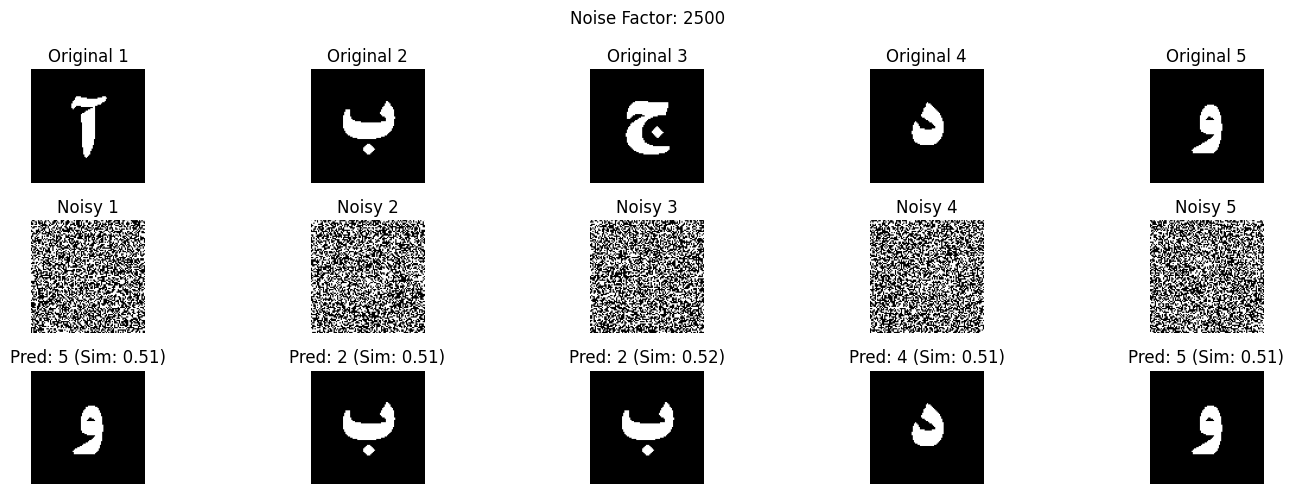

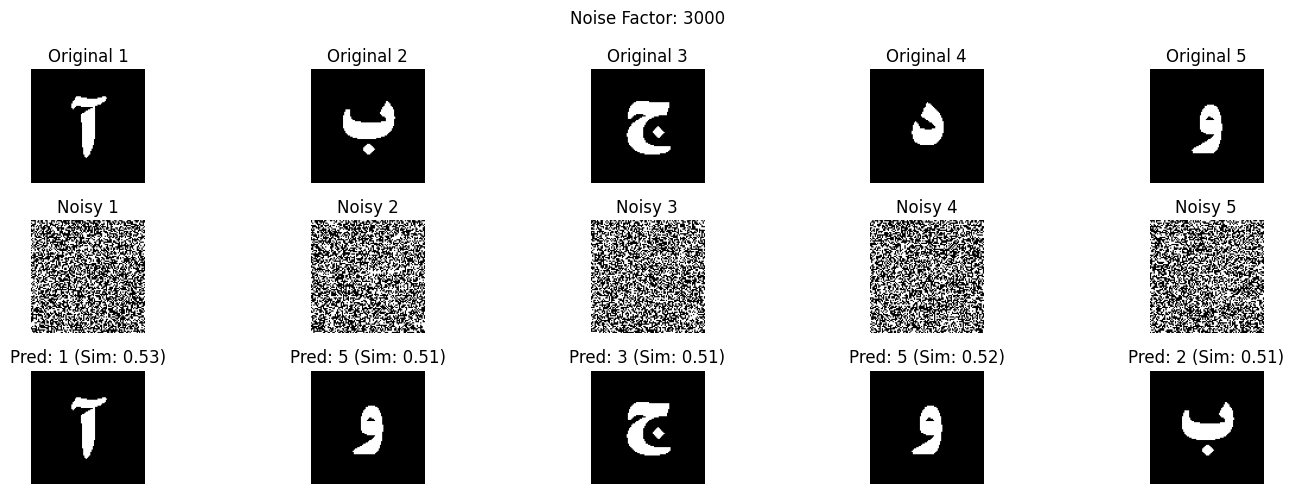

--------------------------------------------------


In [ ]:
if __name__ == "__main__":
    image_paths = [f"/content/{i}.jpg" for i in range(1, 6)]
    data = [convertImageToBinary(path) for path in image_paths]

    network = HammingNetwork(theta=0.5, epsilon=0.1)
    network.train(data)

    results = test_network(network, data, noise_factors=[ 2500 , 3000])
    plot_results(data, results)
    print('--------------------------------------------------')

## 6.3

In [ ]:
def generateMissingPointImages(missing_percentage):
    image_paths = [
        "/content/1.jpg",
        "/content/2.jpg",
        "/content/3.jpg",
        "/content/4.jpg",
        "/content/5.jpg"
    ]

    missing_image_paths = []  # Initialize a list to store images with missing points

    for i, image_path in enumerate(image_paths, start=1):
        missing_image_path = f"/content/missing{i}_miss{missing_percentage}.jpg"
        applyMissingPoints(image_path, missing_image_path, missing_percentage)
        print(f"Image with missing points for {image_path} generated and saved as {missing_image_path}")
        missing_image_paths.append(missing_image_path)  # Add the missing image path to the list

    return missing_image_paths  # Return the list of images with missing points

def applyMissingPoints(input_path, output_path, missing_percentage):
    image = Image.open(input_path)
    img_array = np.array(image)

    # Generate data with missing points
    img_array_with_missing = generateMissingPointsData(img_array, missing_percentage)

    # Convert back to Image object
    img_with_missing = Image.fromarray(img_array_with_missing)

    # Save the new image with a modified name
    img_with_missing.save(output_path, "JPEG")

def generateMissingPointsData(input_data, missing_percentage):

    data_with_missing_points = input_data.copy()

    # Calculate number of points to be set to missing
    total_points = input_data.shape[0] * input_data.shape[1]
    missing_points_count = int(total_points * (missing_percentage / 100))

    # Generate random indices to set to missing
    indices = random.sample(range(total_points), missing_points_count)

    # Set the selected points to -1 (indicating missing data)
    for idx in indices:
        row, col = divmod(idx, input_data.shape[1])  # Convert the flat index to 2D indices
        data_with_missing_points[row, col] = -1  # Set the missing point to -1 for binary data

    return data_with_missing_points

# Example usage
generateMissingPointImages(30)  # Generate images with 30% missing points

<ipython-input-56-2b8fa33e5231>:57: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of -1 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  data_with_missing_points[row, col] = -1  # Set the missing point to -1 for binary data


Image with missing points for /content/1.jpg generated and saved as /content/missing1_miss30.jpg
Image with missing points for /content/2.jpg generated and saved as /content/missing2_miss30.jpg
Image with missing points for /content/3.jpg generated and saved as /content/missing3_miss30.jpg
Image with missing points for /content/4.jpg generated and saved as /content/missing4_miss30.jpg
Image with missing points for /content/5.jpg generated and saved as /content/missing5_miss30.jpg


['/content/missing1_miss30.jpg',
 '/content/missing2_miss30.jpg',
 '/content/missing3_miss30.jpg',
 '/content/missing4_miss30.jpg',
 '/content/missing5_miss30.jpg']

<ipython-input-56-2b8fa33e5231>:57: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of -1 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  data_with_missing_points[row, col] = -1  # Set the missing point to -1 for binary data


Image with missing points for /content/1.jpg generated and saved as /content/missing1_miss66.jpg
Image with missing points for /content/2.jpg generated and saved as /content/missing2_miss66.jpg
Image with missing points for /content/3.jpg generated and saved as /content/missing3_miss66.jpg
Image with missing points for /content/4.jpg generated and saved as /content/missing4_miss66.jpg
Image with missing points for /content/5.jpg generated and saved as /content/missing5_miss66.jpg
Image with missing points for /content/1.jpg generated and saved as /content/missing1_miss67.jpg
Image with missing points for /content/2.jpg generated and saved as /content/missing2_miss67.jpg
Image with missing points for /content/3.jpg generated and saved as /content/missing3_miss67.jpg
Image with missing points for /content/4.jpg generated and saved as /content/missing4_miss67.jpg
Image with missing points for /content/5.jpg generated and saved as /content/missing5_miss67.jpg
Image with missing points for 

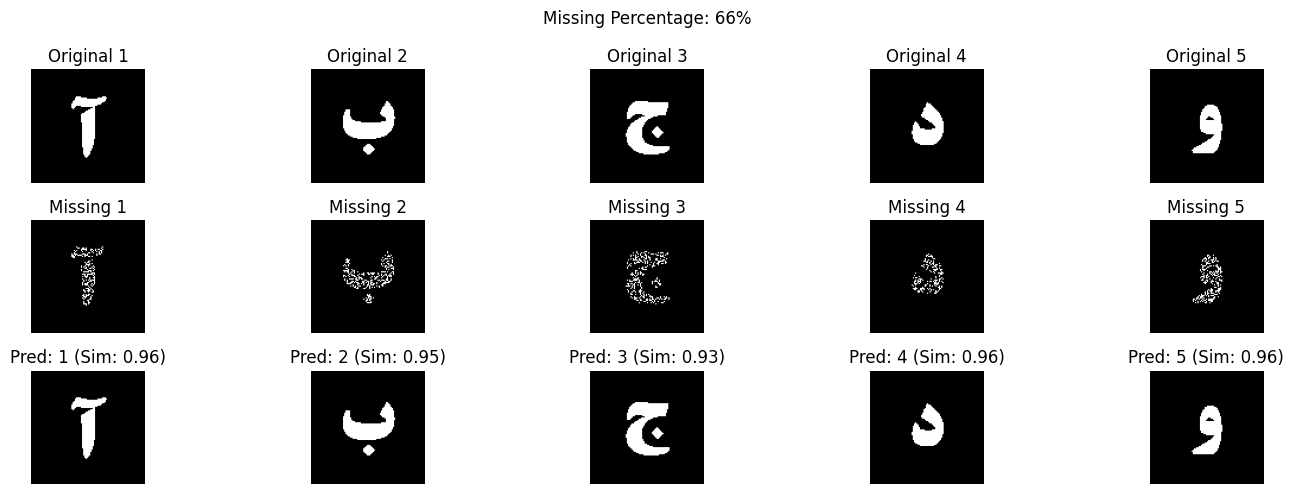

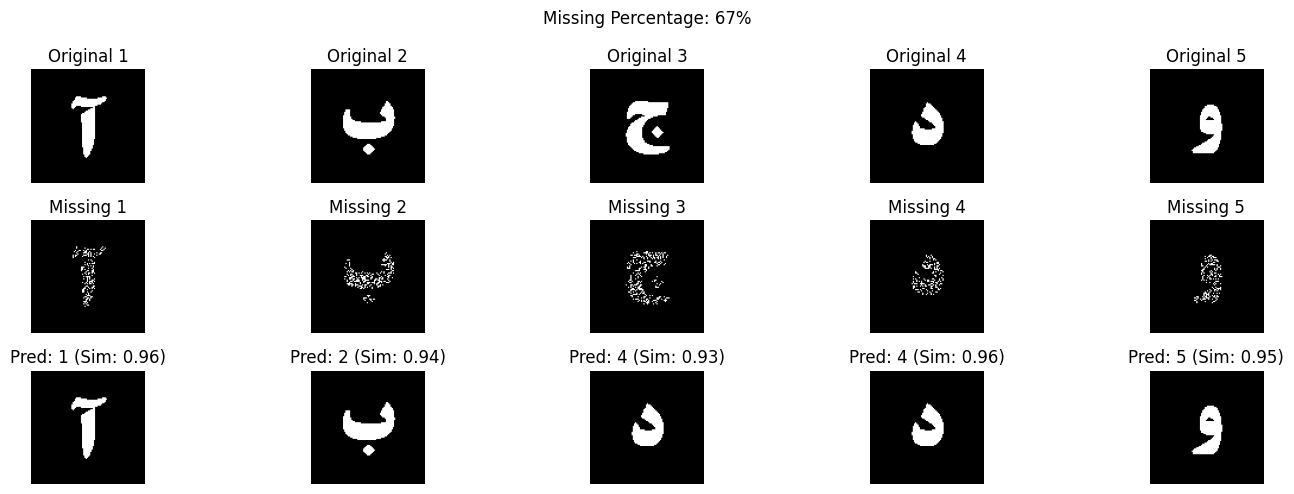

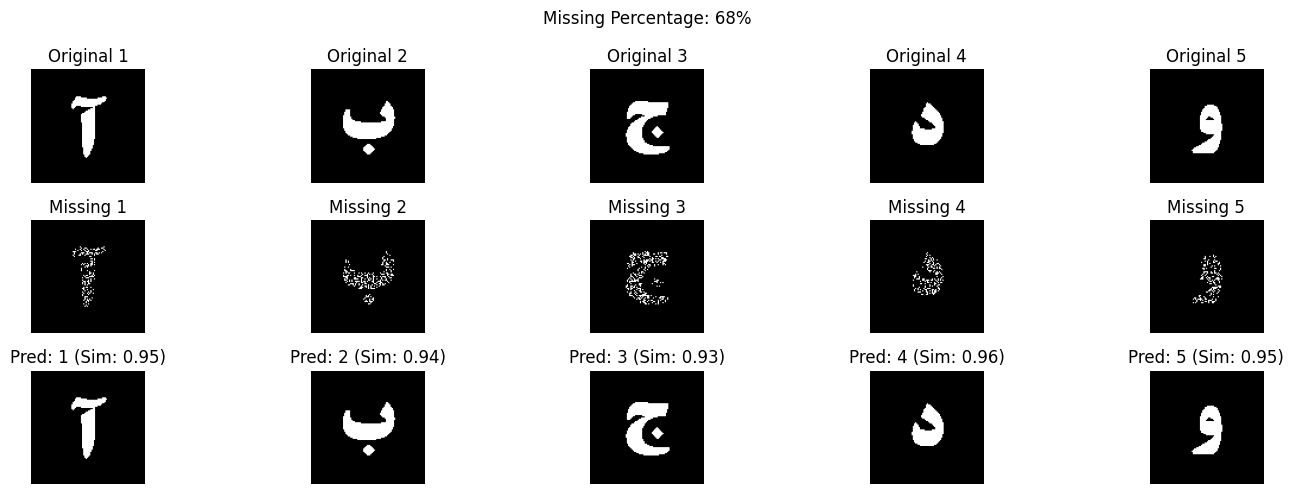

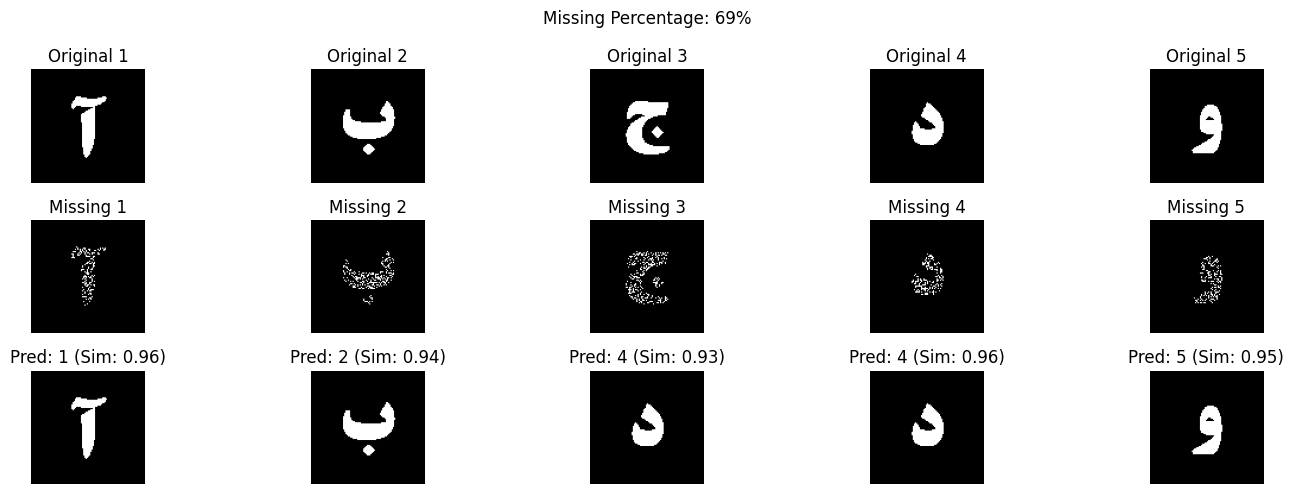

In [ ]:
def test_network_with_missing_points(network, original_data, missing_percentages=[10, 20, 30, 40]):
    results = []

    for missing_percentage in missing_percentages:
        missing_paths = generateMissingPointImages(missing_percentage)  # تولید تصاویر با درصد مختلف از دست دادن نقاط
        missing_data = [convertImageToBinary(path) for path in missing_paths]

        predictions = []
        classifications = []

        # پیش‌بینی برای هر تصویر با نقاط مفقوده
        for missing in missing_data:
            pred, class_idx = network.predict(missing)  # پیش‌بینی با شبکه
            sim = network.calculate_similarity(pred, missing)  # محاسبه شباهت
            predictions.append(pred)
            classifications.append((class_idx, sim))

        results.append({
            'missing_percentage': missing_percentage,
            'missing': missing_data,
            'predictions': predictions,
            'classifications': classifications
        })

    return results

def plot_results_for_missing_data(original_data, results, figsize=(15, 5)):
    for result in results:
        missing_percentage = result['missing_percentage']
        fig, axes = plt.subplots(3, len(original_data), figsize=figsize)
        fig.suptitle(f'Missing Percentage: {missing_percentage}%')

        for i in range(len(original_data)):
            # oroginal pics
            axes[0, i].imshow(original_data[i], cmap='gray')
            axes[0, i].set_title(f'Original {i+1}')
            axes[0, i].axis('off')

            # missing pics
            axes[1, i].imshow(result['missing'][i], cmap='gray')
            axes[1, i].set_title(f'Missing {i+1}')
            axes[1, i].axis('off')

            # نمایش predict pics
            axes[2, i].imshow(result['predictions'][i], cmap='gray')
            class_idx, sim = result['classifications'][i]
            axes[2, i].set_title(f'Pred: {class_idx} (Sim: {sim:.2f})')
            axes[2, i].axis('off')

        plt.tight_layout()
        plt.show()
# Example usage:
image_paths = [f"/content/{i}.jpg" for i in range(1, 6)]
data = [convertImageToBinary(path) for path in image_paths]

network = HammingNetwork(theta=0.5, epsilon=0.1)
network.train(data)

results = test_network_with_missing_points(network, data, missing_percentages=[66,67,68,69])

# رسم نتایج
plot_results_for_missing_data(data, results)

# 4

## 4.1

In [ ]:
#import
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=13)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOc

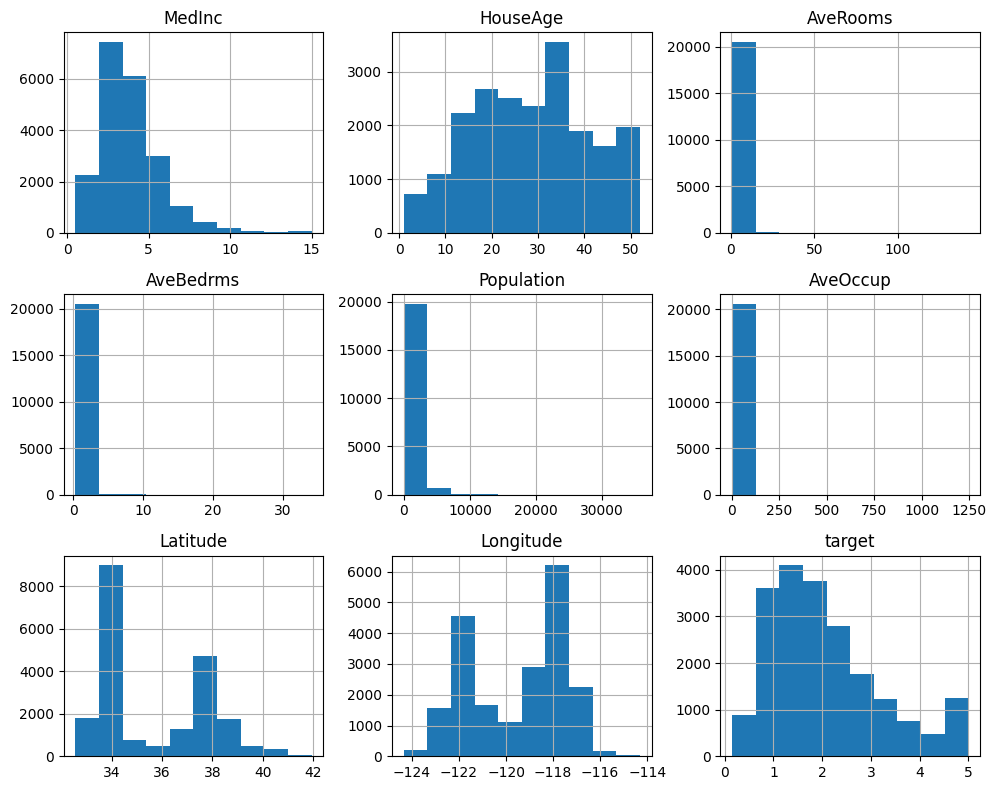

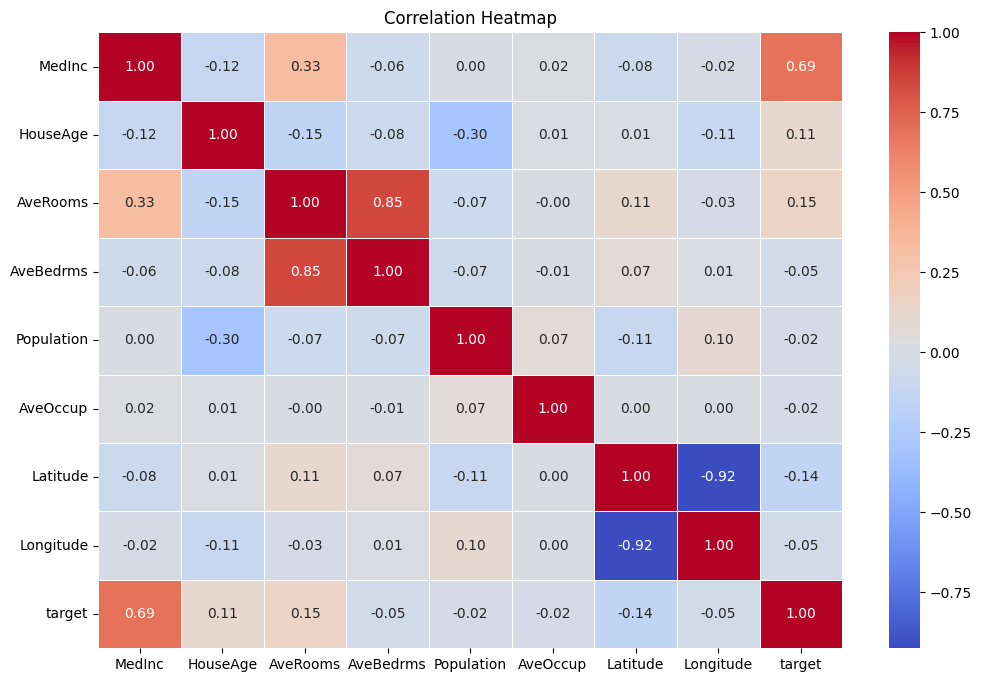

target        1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: target, dtype: float64


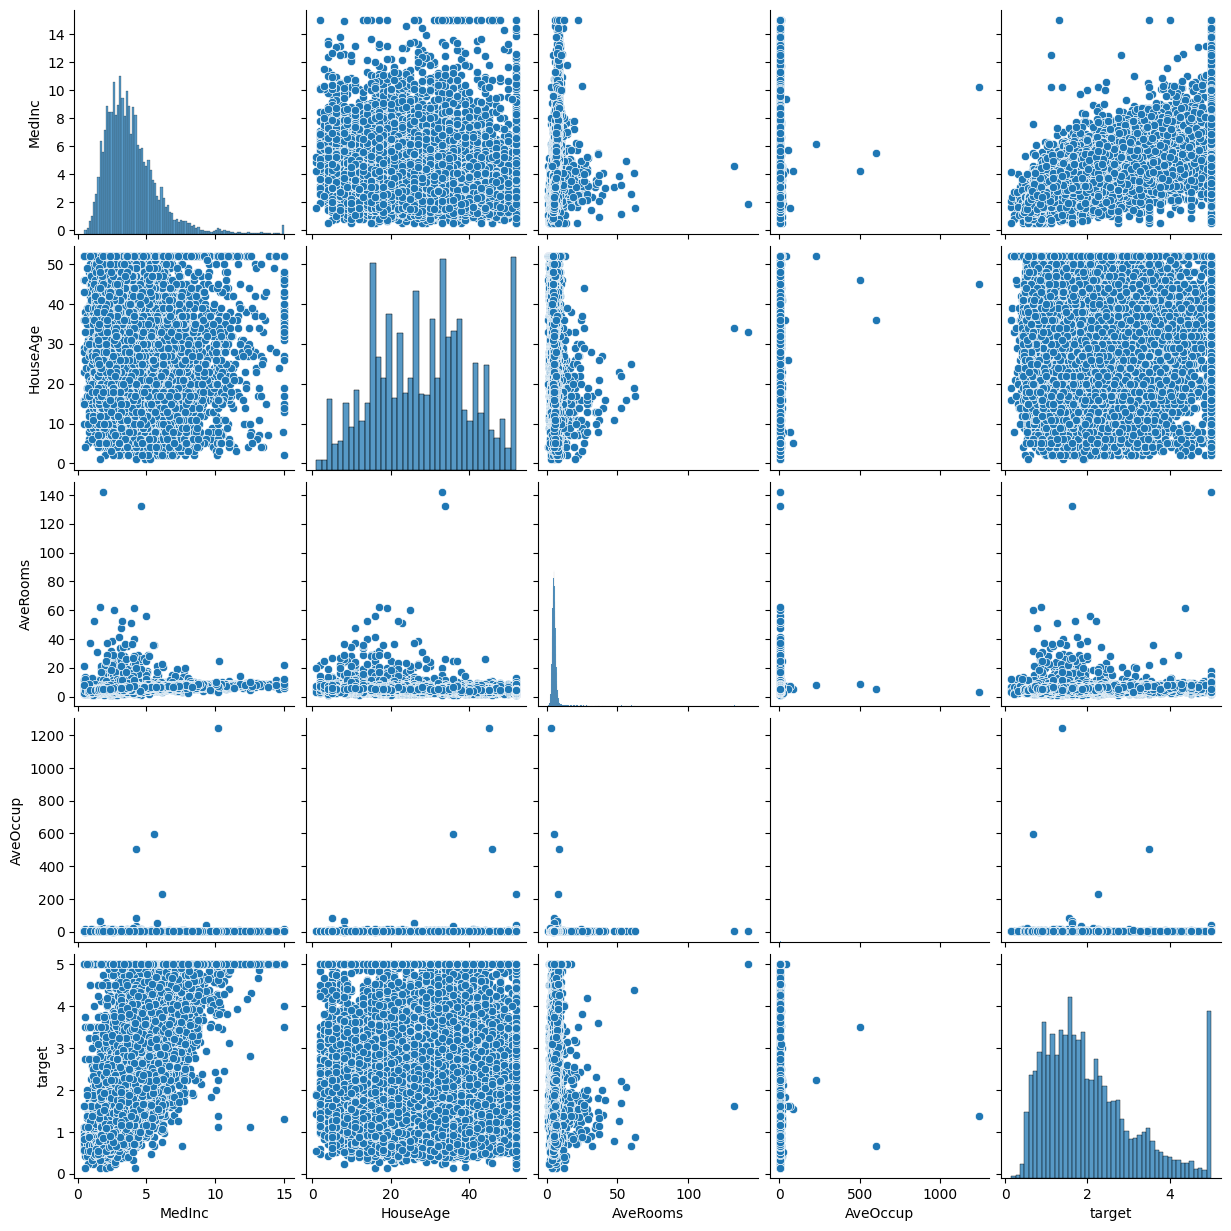

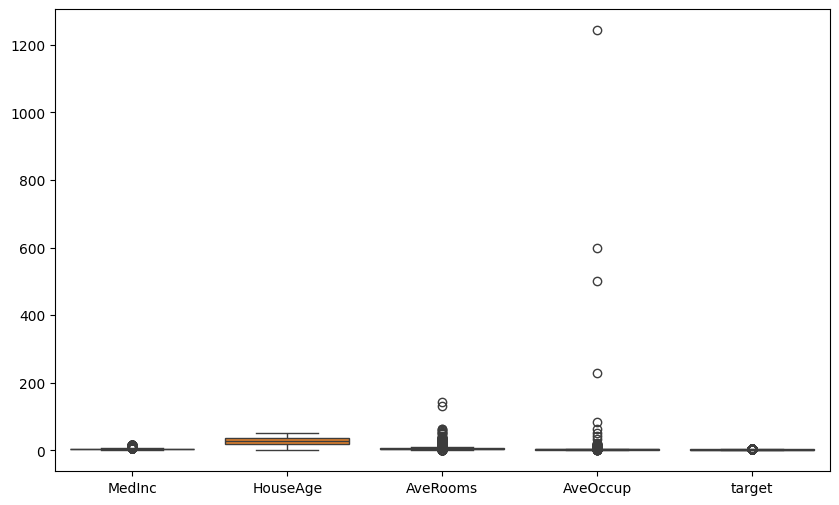

In [ ]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()
correlation_with_target = correlation_matrix['target'].sort_values(ascending=False)
print(correlation_with_target)
sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'target']])
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'target']])
plt.show()

In [ ]:
# create RBF layer
class RBFLayer(layers.Layer):
    def __init__(self, units, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.centroids = self.add_weight(
            name="centroids",
            shape=(self.units, input_shape[1]),
            initializer="uniform",
            trainable=True
        )
        self.gamma = self.add_weight(
            name="gamma",
            shape=(1,),
            initializer="ones",
            trainable=True
        )

    def call(self, inputs):
        diff = tf.expand_dims(inputs, 1) - self.centroids
        dist = tf.reduce_sum(tf.square(diff), axis=-1)
        return tf.exp(-self.gamma * dist)

# مدل با لایه RBF
model_rbf = models.Sequential([
    RBFLayer(10, input_shape=(X_train.shape[1],)),
    layers.Dense(1)
])

# کامپایل مدل
model_rbf.compile(optimizer='adam', loss='mean_squared_error')

# آموزش مدل
model_rbf.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# ارزیابی مدل
loss_rbf = model_rbf.evaluate(X_test, y_test)
print(f'RBF Model Loss: {loss_rbf}')

<ipython-input-94-4c2dd914f094>:4: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(RBFLayer, self).__init__(**kwargs)


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4683
RBF Model Loss: 0.46318989992141724


In [ ]:
model_dense = models.Sequential([
    layers.Dense(16, input_dim=X_train_scaled.shape[1], activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

# کامپایل مدل
model_dense.compile(optimizer='adam', loss='mean_squared_error')

# آموزش مدل
model_dense.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)

# ارزیابی مدل
loss_dense = model_dense.evaluate(X_test_scaled, y_test)
print(f'Dense Model Loss: {loss_dense}')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3117
Dense Model Loss: 0.3086976706981659
